In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def metropolis_sampler(target_density, initial_state, n_iterations, proposal_std=0.5):
    """
    Runs the Metropolis algorithm to sample from a target distribution.

    Args:
        target_density (function): A function that returns a value proportional 
                                   to the probability density at x.
        initial_state (float): The starting point of the chain.
        n_iterations (int): The number of samples to generate.
        proposal_std (float): Standard deviation for the Gaussian proposal distribution.

    Returns:
        numpy.ndarray: Array of sampled values.
    """
    current_state = initial_state
    samples = np.zeros(n_iterations)
    
    # Track acceptance rate for tuning
    accepted_count = 0

    for i in range(n_iterations):
        # 1. Propose a new state x* from a symmetric proposal distribution q(x*|x)
        #    Here we use a normal distribution centered at the current state.
        proposal = np.random.normal(current_state, proposal_std)

        # 2. Calculate the acceptance probability alpha
        #    alpha = min(1, P(x*) / P(x))
        #    Note: Since the proposal is symmetric (Gaussian), the q factors cancel out.
        p_current = target_density(current_state)
        p_proposal = target_density(proposal)

        # Avoid division by zero if the chain starts in a zero-probability region
        if p_current == 0:
            acceptance_ratio = 1.0
        else:
            acceptance_ratio = p_proposal / p_current

        # 3. Accept or Reject
        #    Generate a uniform random number u in [0, 1]
        if np.random.rand() < acceptance_ratio:
            current_state = proposal
            accepted_count += 1
        else:
            # Reject: current_state remains the same
            pass

        samples[i] = current_state

    print(f"Acceptance Rate: {accepted_count / n_iterations:.2%}")
    return samples
 

Acceptance Rate: 52.77%


/tmp/ipykernel_14866/3878550735.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization_constant = np.trapz(y_vals, x_vals)


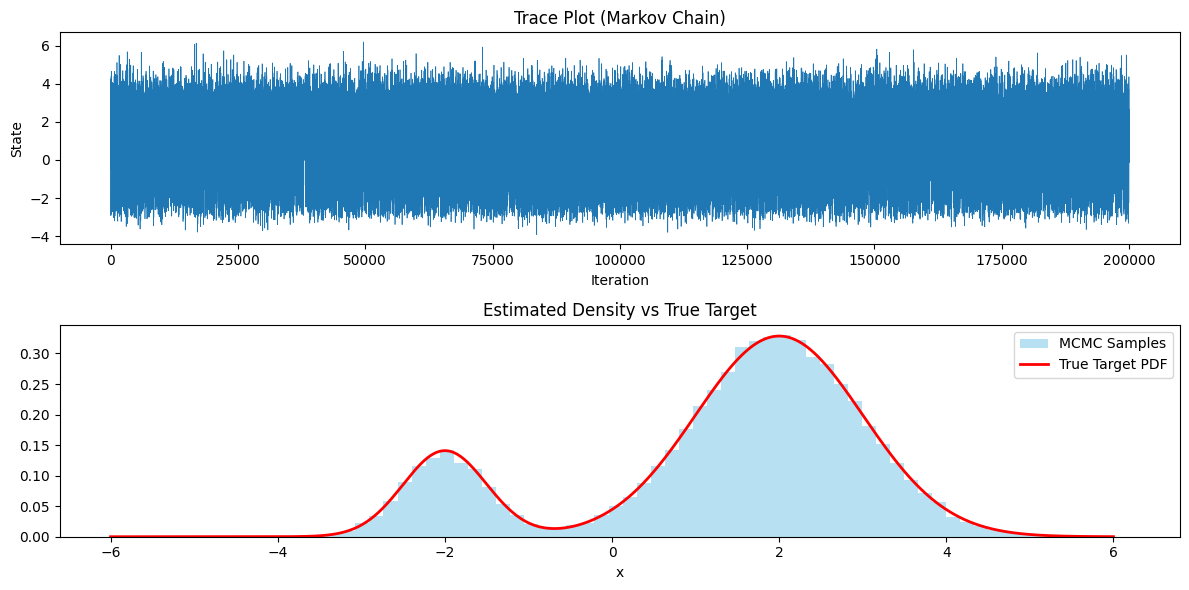

In [ ]:
# Define a target distribution: Mixture of two Gaussians (unnormalized)
# P(x) ~ 0.3 * N(-2, 0.5^2) + 0.7 * N(2, 1.0^2)
def target_pdf(x):
    return (0.3 * np.exp(-0.5 * (x + 2)**2 / 0.25) + 
            0.7 * np.exp(-0.5 * (x - 2)**2 / 1.0))

# Parameters
n_samples = 200000
start_x = 0.0  # Start at 0

# Run the sampler
chain = metropolis_sampler(target_pdf, start_x, n_samples, proposal_std=2.0)

# Visualization
plt.figure(figsize=(12, 6))

# 1. Trace plot (shows the path of the chain)
plt.subplot(2, 1, 1)
plt.plot(chain, lw=0.5)
plt.title("Trace Plot (Markov Chain)")
plt.ylabel("State")
plt.xlabel("Iteration")

# 2. Histogram vs True Density
plt.subplot(2, 1, 2)
plt.hist(chain, bins=60, density=True, alpha=0.6, color='skyblue', label='MCMC Samples')

# Plot true density for comparison
x_vals = np.linspace(-6, 6, 1000)
y_vals = target_pdf(x_vals)
# Normalize true density numerically for plotting
normalization_constant = np.trapz(y_vals, x_vals)
plt.plot(x_vals, y_vals / normalization_constant, 'r-', lw=2, label='True Target PDF')

plt.title("Estimated Density vs True Target")
plt.xlabel("x")
plt.legend()

plt.tight_layout()
plt.show()
